# Model Trainer — A / B / C Pipeline Shootout

**Goal:** Compare three feature-engineering pipelines that differ only in how
the close-price series is transformed before being fed into a Random Forest
classifier.

| Pipeline | Differencing | d value |
|----------|-------------|---------|
| **A** | None (raw price) | d = 0 |
| **B** | Integer differencing (returns) | d = 1 |
| **C** | Fractional differentiation (FFD) | d = x* |

*\*x is the minimum d that passes the ADF test at p < 0.05*

All three pipelines share the **same target**: the sign of the 5-bar forward
return, and the **same train / test split** (time-based 80 / 20).

## 1 — Install / Import Dependencies and Set Reproducibility

In [24]:
%pip install pandas pyarrow numpy scikit-learn statsmodels scipy matplotlib seaborn --quiet

Note: you may need to restart the kernel to use updated packages.


In [25]:
import os, warnings, pathlib
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

import numpy as np
import pandas as pd
import pyarrow.parquet as pq
from scipy.signal import lfilter
from statsmodels.tsa.stattools import adfuller

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, log_loss,
)
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# ── reproducibility ──────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)

print("All imports OK.")

All imports OK.


## 2 — Load Dollar Bars Data and Run Data Quality Checks

We load a representative subset of tickers from `dollar_bars_parquet/` (the raw
dollar-bar files) so that the notebook runs in reasonable time.  Data quality
checks cover: missing values, duplicate timestamps, monotonicity, and basic
summary statistics.

In [26]:
RAW_DIR = "./dollar_bars_parquet"
FRACDIFF_DIR = "./dollar_bars_fracdiff_parquet"

# Representative tickers — mix of mega-cap, mid-cap, sectors
TICKERS = ["AAPL", "MSFT", "AMZN", "JPM", "XOM", "JNJ", "NVDA", "META",
           "BAC", "PFE", "KO", "DIS", "INTC", "CSCO", "AMD"]

def safe_read_parquet(path: str) -> pd.DataFrame:
    """Read parquet with fallback for extension-metadata issues."""
    try:
        return pd.read_parquet(path, engine="pyarrow")
    except Exception:
        table = pq.read_table(path, arrow_extensions_enabled=False)
        return table.to_pandas()

# ── load raw dollar bars ─────────────────────────────────────────────────────
raw_frames: dict[str, pd.DataFrame] = {}
for ticker in TICKERS:
    p = os.path.join(RAW_DIR, f"{ticker}.parquet")
    if os.path.isfile(p):
        raw_frames[ticker] = safe_read_parquet(p)

print(f"Loaded {len(raw_frames)} / {len(TICKERS)} tickers from {RAW_DIR}")
print(f"Tickers loaded: {sorted(raw_frames.keys())}")

Loaded 15 / 15 tickers from ./dollar_bars_parquet
Tickers loaded: ['AAPL', 'AMD', 'AMZN', 'BAC', 'CSCO', 'DIS', 'INTC', 'JNJ', 'JPM', 'KO', 'META', 'MSFT', 'NVDA', 'PFE', 'XOM']


In [27]:
# ── Data Quality Checks ───────────────────────────────────────────────────────
quality_rows = []
for ticker, df in raw_frames.items():
    ts_col = "end_ts" if "end_ts" in df.columns else ("start_ts" if "start_ts" in df.columns else None)
    n_rows = len(df)
    n_null_close = int(df["close"].isna().sum()) if "close" in df.columns else n_rows
    n_dup_ts = 0
    ts_monotonic = None
    if ts_col:
        ts = pd.to_datetime(df[ts_col], errors="coerce")
        n_dup_ts = int(ts.duplicated().sum())
        ts_monotonic = bool(ts.dropna().is_monotonic_increasing)

    quality_rows.append({
        "ticker": ticker,
        "rows": n_rows,
        "columns": list(df.columns),
        "null_close": n_null_close,
        "dup_timestamps": n_dup_ts,
        "ts_monotonic": ts_monotonic,
        "close_min": df["close"].min() if "close" in df.columns else None,
        "close_max": df["close"].max() if "close" in df.columns else None,
    })

quality_df = pd.DataFrame(quality_rows).set_index("ticker")
display(quality_df.drop(columns="columns"))

# Show column schema from first ticker
first_ticker = list(raw_frames.keys())[0]
print(f"\nColumn schema ({first_ticker}):")
print(raw_frames[first_ticker].dtypes.to_string())

,rows,null_close,dup_timestamps,ts_monotonic,close_min,close_max
ticker,,,,,,
AAPL,72247,0,14468,True,124.2100,288.2600
MSFT,76822,0,19510,True,213.5800,561.0000
AMZN,69466,0,11205,True,81.5700,3420.5100
JPM,74123,0,17373,True,101.4200,337.1700
XOM,68333,0,15511,True,64.3300,142.2601
JNJ,79079,0,23571,True,141.5099,229.4700
NVDA,62996,0,4070,True,87.1301,1255.2950
META,70748,0,9963,True,88.0900,795.9177
BAC,68212,0,12337,True,24.9650,57.5050



Column schema (AAPL):
date                     object
start_ts         datetime64[ns]
end_ts           datetime64[ns]
open                    float64
high                    float64
low                     float64
close                   float64
volume                  float64
dollar_volume           float64
threshold               float64
symbol                      str


## 3 — Create the 5-Bar Forward Direction Target

The label for every bar is:

$$y_t = \text{sign}\!\bigl(\text{close}_{t+5} - \text{close}_t\bigr)$$

mapped to `{0, 1}` (down / up).  Bars where the forward return is exactly 0
are dropped to avoid an ambiguous class.

In [28]:
HORIZON = 5  # number of bars to look ahead

def make_target(df: pd.DataFrame, horizon: int = HORIZON) -> pd.Series:
    """Return binary direction label: 1 = up, 0 = down."""
    close = pd.to_numeric(df["close"], errors="coerce")
    fwd_ret = close.shift(-horizon) / close - 1.0
    label = (fwd_ret > 0).astype(float)
    label[fwd_ret == 0] = np.nan          # drop ambiguous flat bars
    label[fwd_ret.isna()] = np.nan        # drop tail rows with no future
    return label.rename("target")

# ── attach target to every ticker frame ──────────────────────────────────────
for ticker in list(raw_frames):
    df = raw_frames[ticker].copy()
    df["target"] = make_target(df, HORIZON)
    raw_frames[ticker] = df

# Quick class-balance check
balance_rows = []
for ticker, df in raw_frames.items():
    t = df["target"].dropna()
    balance_rows.append({
        "ticker": ticker,
        "n_labeled": len(t),
        "pct_up": round(t.mean() * 100, 2),
        "pct_down": round((1 - t.mean()) * 100, 2),
    })
balance_df = pd.DataFrame(balance_rows).set_index("ticker")
display(balance_df)
print(f"\nOverall up %: {balance_df['pct_up'].mean():.2f}%")

,n_labeled,pct_up,pct_down
ticker,,,
AAPL,64139,51.19,48.81
MSFT,64620,50.98,49.02
AMZN,64178,50.90,49.10
JPM,62445,51.63,48.37
XOM,59683,51.00,49.00
JNJ,61930,51.17,48.83
NVDA,62188,51.85,48.15
META,67044,50.79,49.21
BAC,60670,50.43,49.57



Overall up %: 50.85%


## 4 — Build Feature Set A: Raw-Price Inputs ($d = 0$)

Pipeline A uses **no differencing** at all.  The feature matrix is built from
the raw close price plus simple rolling statistics computed directly on the
price level.

| Feature | Description |
|---------|-------------|
| `close` | Raw close price |
| `log_close` | log(close) |
| `rolling_mean_20` | 20-bar simple moving average |
| `rolling_std_20` | 20-bar rolling standard deviation |
| `close_to_sma` | close / SMA-20 — mean-reversion signal |

In [29]:
FEATURES_A = ["close", "log_close", "rolling_mean_20", "rolling_std_20", "close_to_sma"]

def build_features_a(df: pd.DataFrame) -> pd.DataFrame:
    """Pipeline A — raw-price features (d = 0)."""
    out = pd.DataFrame(index=df.index)
    close = pd.to_numeric(df["close"], errors="coerce")

    out["close"]           = close
    out["log_close"]       = np.log(close.clip(lower=1e-8))
    out["rolling_mean_20"] = close.rolling(20).mean()
    out["rolling_std_20"]  = close.rolling(20).std()
    out["close_to_sma"]    = close / out["rolling_mean_20"]
    return out

# ── build for every ticker ───────────────────────────────────────────────────
features_a: dict[str, pd.DataFrame] = {}
for ticker, df in raw_frames.items():
    features_a[ticker] = build_features_a(df)

print(f"Feature Set A columns: {FEATURES_A}")
display(features_a[list(features_a)[0]].describe().round(4))

Feature Set A columns: ['close', 'log_close', 'rolling_mean_20', 'rolling_std_20', 'close_to_sma']


,close,log_close,rolling_mean_20,rolling_std_20,close_to_sma
count,72247.0000,72247.0000,72228.0000,72228.0000,72228.0000
mean,195.1031,5.2552,195.0963,0.5806,1.0001
std,37.4523,0.1913,37.4423,0.4913,0.0053
min,124.2100,4.8220,124.5956,0.0000,0.9225
25%,166.9700,5.1178,166.9512,0.2972,0.9978
50%,189.2200,5.2429,189.1955,0.4683,1.0001
75%,225.7258,5.4193,225.6730,0.7269,1.0024
max,288.2600,5.6639,287.2867,10.1469,1.0657


## 5 — Build Feature Set B: Integer-Differenced Inputs ($d = 1$)

Pipeline B applies **first-order differencing** (standard returns / log-returns)
so the series is stationary, but at the cost of losing all long-run memory.

| Feature | Description |
|---------|-------------|
| `ret_1` | 1-bar simple return |
| `log_ret_1` | 1-bar log return |
| `rolling_mean_ret_20` | 20-bar rolling mean of returns |
| `rolling_std_ret_20` | 20-bar rolling std of returns (vol) |
| `ret_to_vol` | return / rolling vol — pseudo Sharpe |

In [30]:
FEATURES_B = ["ret_1", "log_ret_1", "rolling_mean_ret_20", "rolling_std_ret_20", "ret_to_vol"]

def build_features_b(df: pd.DataFrame) -> pd.DataFrame:
    """Pipeline B — integer-differenced features (d = 1)."""
    out = pd.DataFrame(index=df.index)
    close = pd.to_numeric(df["close"], errors="coerce")

    out["ret_1"]               = close.pct_change()
    out["log_ret_1"]           = np.log(close / close.shift(1))
    out["rolling_mean_ret_20"] = out["ret_1"].rolling(20).mean()
    out["rolling_std_ret_20"]  = out["ret_1"].rolling(20).std()
    out["ret_to_vol"]          = out["ret_1"] / out["rolling_std_ret_20"].replace(0, np.nan)
    return out

# ── build for every ticker ───────────────────────────────────────────────────
features_b: dict[str, pd.DataFrame] = {}
for ticker, df in raw_frames.items():
    features_b[ticker] = build_features_b(df)

print(f"Feature Set B columns: {FEATURES_B}")
display(features_b[list(features_b)[0]].describe().round(6))

Feature Set B columns: ['ret_1', 'log_ret_1', 'rolling_mean_ret_20', 'rolling_std_ret_20', 'ret_to_vol']


,ret_1,log_ret_1,rolling_mean_ret_20,rolling_std_ret_20,ret_to_vol
count,72246.000000,72246.000000,72227.000000,72227.000000,71937.000000
mean,0.000007,0.000005,0.000007,0.001788,0.004927
std,0.002192,0.002194,0.000480,0.001274,1.023301
min,-0.081234,-0.084723,-0.005081,0.000000,-4.489159
25%,-0.000733,-0.000733,-0.000213,0.001071,-0.456440
50%,0.000000,0.000000,0.000008,0.001532,0.000000
75%,0.000778,0.000777,0.000241,0.002175,0.488680
max,0.057964,0.056346,0.004729,0.020200,4.530296


## 6 — Build Feature Set C: Fractionally-Differenced Inputs ($d = x$)

The fractional differentiation was already computed in the
`FractionalDifferentiation.ipynb` notebook and saved to
`dollar_bars_fracdiff_parquet/`.  Each file contains the original columns
**plus** a `fd_close_d<x>` column, `best_d`, and `best_pvalue`.

We load those pre-computed files, extract the `fd_close` column and the
optimal $d$, then build rolling features on the fractionally-differenced
series — giving us stationarity **and** memory preservation.

In [31]:
FEATURES_C = ["fd_close", "fd_rolling_mean_20", "fd_rolling_std_20", "fd_to_sma", "fd_ret_1"]

# ── load pre-computed fracdiff parquets ──────────────────────────────────────
fracdiff_frames: dict[str, pd.DataFrame] = {}
d_values: dict[str, float] = {}

for ticker in TICKERS:
    p = os.path.join(FRACDIFF_DIR, f"{ticker}.parquet")
    if not os.path.isfile(p):
        continue
    fd_df = safe_read_parquet(p)

    # find the fd_close_d* column
    fd_col = next((c for c in fd_df.columns if c.startswith("fd_close_d")), None)
    if fd_col is None:
        print(f"  {ticker}: no fd_close column found — skipping")
        continue

    fd_df = fd_df.rename(columns={fd_col: "fd_close"})
    best_d = fd_df["best_d"].dropna().iloc[0] if "best_d" in fd_df.columns else np.nan
    d_values[ticker] = float(best_d)
    fracdiff_frames[ticker] = fd_df

print(f"Loaded fracdiff data for {len(fracdiff_frames)} / {len(TICKERS)} tickers")
print("Optimal d values:")
for t, d in sorted(d_values.items()):
    print(f"  {t}: d = {d:.2f}")

Loaded fracdiff data for 15 / 15 tickers
Optimal d values:
  AAPL: d = 0.25
  AMD: d = 0.30
  AMZN: d = 0.15
  BAC: d = 0.25
  CSCO: d = 0.25
  DIS: d = 0.20
  INTC: d = 0.30
  JNJ: d = 0.35
  JPM: d = 0.25
  KO: d = 0.15
  META: d = 0.20
  MSFT: d = 0.25
  NVDA: d = 0.25
  PFE: d = 0.10
  XOM: d = 0.25


In [32]:
def build_features_c(fd_df: pd.DataFrame) -> pd.DataFrame:
    """Pipeline C — features built on pre-computed fractionally-differenced close."""
    out = pd.DataFrame(index=fd_df.index)
    fd = pd.to_numeric(fd_df["fd_close"], errors="coerce")

    out["fd_close"]           = fd
    out["fd_rolling_mean_20"] = fd.rolling(20).mean()
    out["fd_rolling_std_20"]  = fd.rolling(20).std()
    out["fd_to_sma"]          = fd / out["fd_rolling_mean_20"].replace(0, np.nan)
    out["fd_ret_1"]           = fd.diff()
    return out

# ── build for every ticker ───────────────────────────────────────────────────
features_c: dict[str, pd.DataFrame] = {}
for ticker, fd_df in fracdiff_frames.items():
    features_c[ticker] = build_features_c(fd_df)

print(f"Feature Set C columns: {FEATURES_C}")
display(features_c[list(features_c)[0]].describe().round(6))

Feature Set C columns: ['fd_close', 'fd_rolling_mean_20', 'fd_rolling_std_20', 'fd_to_sma', 'fd_ret_1']


,fd_close,fd_rolling_mean_20,fd_rolling_std_20,fd_to_sma,fd_ret_1
count,69444.000000,69425.000000,69425.000000,69425.000000,69443.000000
mean,22.144930,22.144456,0.420592,1.000223,0.000146
std,4.673538,4.644287,0.326283,0.030691,0.426477
min,6.392856,11.504970,0.000249,0.274873,-17.852206
25%,18.656486,18.667540,0.235913,0.988689,-0.150254
50%,21.792763,21.789062,0.351656,1.000062,-0.000879
75%,25.662959,25.648731,0.514938,1.012319,0.150442
max,39.816705,36.259154,6.388700,1.478388,11.499171


## 7 — Align Features / Labels and Apply Time-Based Splits

We join each feature set with the target, drop any row with NaN, and
split **80 / 20 by row order** (time-based, no shuffle) so no future
information leaks into training.

In [33]:
TRAIN_FRAC = 0.80

def align_and_split(feat_dict, raw_dict, feat_cols, pipeline_label):
    """
    Join features + target, drop NaN, time-split 80/20.
    Returns pooled (X_train, y_train, X_test, y_test) across all tickers.
    """
    X_trains, y_trains, X_tests, y_tests = [], [], [], []

    for ticker in feat_dict:
        feat = feat_dict[ticker][feat_cols].copy()
        target = raw_dict[ticker]["target"].copy()

        combined = feat.join(target).dropna()
        if len(combined) < 50:
            continue

        split_idx = int(len(combined) * TRAIN_FRAC)
        train = combined.iloc[:split_idx]
        test  = combined.iloc[split_idx:]

        X_trains.append(train[feat_cols])
        y_trains.append(train["target"])
        X_tests.append(test[feat_cols])
        y_tests.append(test["target"])

    X_train = pd.concat(X_trains)
    y_train = pd.concat(y_trains)
    X_test  = pd.concat(X_tests)
    y_test  = pd.concat(y_tests)

    print(f"Pipeline {pipeline_label}:  train {len(X_train):,} rows  |  test {len(X_test):,} rows  |  "
          f"train up% {y_train.mean()*100:.1f}  |  test up% {y_test.mean()*100:.1f}")
    return X_train, y_train, X_test, y_test

# ── Pipeline A (d=0) ────────────────────────────────────────────────────────
X_train_a, y_train_a, X_test_a, y_test_a = align_and_split(
    features_a, raw_frames, FEATURES_A, "A (d=0)")

# ── Pipeline B (d=1) ────────────────────────────────────────────────────────
X_train_b, y_train_b, X_test_b, y_test_b = align_and_split(
    features_b, raw_frames, FEATURES_B, "B (d=1)")

# ── Pipeline C (d=x, fracdiff) ──────────────────────────────────────────────
# For C, the target comes from raw_frames but we need to ensure index alignment
# with the fracdiff frames.  Re-attach target to fracdiff frames first.
raw_for_c: dict[str, pd.DataFrame] = {}
for ticker in features_c:
    fd_df = fracdiff_frames[ticker].copy()
    fd_df["target"] = make_target(fd_df, HORIZON)
    raw_for_c[ticker] = fd_df

X_train_c, y_train_c, X_test_c, y_test_c = align_and_split(
    features_c, raw_for_c, FEATURES_C, "C (d=x)")

Pipeline A (d=0):  train 755,403 rows  |  test 188,860 rows  |  train up% 50.8  |  test up% 51.1
Pipeline B (d=1):  train 752,292 rows  |  test 188,081 rows  |  train up% 50.8  |  test up% 51.1
Pipeline C (d=x):  train 724,010 rows  |  test 181,008 rows  |  train up% 50.9  |  test up% 51.1


## 8 — Train Random Forest Models for A / B / C Pipelines

We train identical `RandomForestClassifier` hyper-parameters across all
three pipelines so the **only** difference is the feature engineering.
Features are standard-scaled before training.

In [34]:
RF_PARAMS = dict(
    n_estimators=500,
    max_depth=6,
    min_samples_leaf=50,
    max_features="sqrt",
    class_weight="balanced",
    n_jobs=-1,
    random_state=SEED,
)

def train_pipeline(X_train, y_train, X_test, label):
    """Scale, fit RF, return (model, scaler, y_prob_test, y_pred_test)."""
    scaler = StandardScaler()
    Xs_train = scaler.fit_transform(X_train)
    Xs_test  = scaler.transform(X_test)

    rf = RandomForestClassifier(**RF_PARAMS)
    rf.fit(Xs_train, y_train)

    y_prob = rf.predict_proba(Xs_test)[:, 1]
    y_pred = rf.predict(Xs_test)
    print(f"Pipeline {label} trained — {rf.n_estimators} trees, depth {rf.max_depth}")
    return rf, scaler, y_prob, y_pred

# ── Train ────────────────────────────────────────────────────────────────────
rf_a, sc_a, prob_a, pred_a = train_pipeline(X_train_a, y_train_a, X_test_a, "A (d=0)")
rf_b, sc_b, prob_b, pred_b = train_pipeline(X_train_b, y_train_b, X_test_b, "B (d=1)")
rf_c, sc_c, prob_c, pred_c = train_pipeline(X_train_c, y_train_c, X_test_c, "C (d=x)")

Pipeline A (d=0) trained — 500 trees, depth 6
Pipeline B (d=1) trained — 500 trees, depth 6
Pipeline C (d=x) trained — 500 trees, depth 6


## 9 — Evaluate Predictive Performance vs Baselines

Baselines:
- **Random** — predict class with 50/50 coin flip
- **Majority** — always predict the majority class in the test set

Metrics reported: Accuracy, F1 (macro), Precision, Recall, Log-Loss.

In [35]:
def evaluate(y_true, y_pred, y_prob, label):
    """Return a dict of classification metrics."""
    return {
        "pipeline": label,
        "accuracy":  accuracy_score(y_true, y_pred),
        "f1_macro":  f1_score(y_true, y_pred, average="macro"),
        "precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall":    recall_score(y_true, y_pred, average="macro", zero_division=0),
        "log_loss":  log_loss(y_true, y_prob, labels=[0, 1]),
    }

# ── baselines (computed against the largest test set — pipeline A) ───────────
np.random.seed(SEED)
random_pred = np.random.choice([0, 1], size=len(y_test_a))
random_prob = np.full(len(y_test_a), 0.5)
majority_class = int(y_test_a.mode().iloc[0])
majority_pred = np.full(len(y_test_a), majority_class)
majority_prob = np.full(len(y_test_a), y_test_a.mean() if majority_class == 1 else 1 - y_test_a.mean())

results = [
    evaluate(y_test_a, random_pred,   random_prob,   "Random Baseline"),
    evaluate(y_test_a, majority_pred,  majority_prob, "Majority Baseline"),
    evaluate(y_test_a, pred_a, prob_a, "A  (d=0, raw)"),
    evaluate(y_test_b, pred_b, prob_b, "B  (d=1, returns)"),
    evaluate(y_test_c, pred_c, prob_c, "C  (d=x, fracdiff)"),
]

results_df = pd.DataFrame(results).set_index("pipeline")
display(results_df.round(4))

,accuracy,f1_macro,precision,recall,log_loss
pipeline,,,,,
Random Baseline,0.4986,0.4986,0.4986,0.4986,0.6931
Majority Baseline,0.5109,0.3382,0.2555,0.5000,0.6929
"A (d=0, raw)",0.5004,0.4870,0.4968,0.4971,0.6934
"B (d=1, returns)",0.5042,0.4713,0.4987,0.4990,0.6933
"C (d=x, fracdiff)",0.4961,0.4961,0.4961,0.4961,0.6934


In [36]:
# ── Per-pipeline classification reports ───────────────────────────────────────
for label, yt, yp in [("A (d=0)", y_test_a, pred_a),
                       ("B (d=1)", y_test_b, pred_b),
                       ("C (d=x)", y_test_c, pred_c)]:
    print(f"\n{'='*50}")
    print(f"  Classification Report — Pipeline {label}")
    print(f"{'='*50}")
    print(classification_report(yt, yp, target_names=["Down", "Up"], zero_division=0))


  Classification Report — Pipeline A (d=0)
              precision    recall  f1-score   support

        Down       0.48      0.35      0.40     92364
          Up       0.51      0.65      0.57     96496

    accuracy                           0.50    188860
   macro avg       0.50      0.50      0.49    188860
weighted avg       0.50      0.50      0.49    188860


  Classification Report — Pipeline B (d=1)
              precision    recall  f1-score   support

        Down       0.49      0.26      0.34     91965
          Up       0.51      0.74      0.60     96116

    accuracy                           0.50    188081
   macro avg       0.50      0.50      0.47    188081
weighted avg       0.50      0.50      0.47    188081


  Classification Report — Pipeline C (d=x)
              precision    recall  f1-score   support

        Down       0.49      0.50      0.49     88570
          Up       0.51      0.50      0.50     92438

    accuracy                           0.50    181

## 10 — Run Stationarity and Memory Diagnostics

For each pipeline we run the **Augmented Dickey-Fuller** test on the primary
feature column (pooled across tickers) to verify stationarity, and report
the auto-correlation at lag 1 as a proxy for retained memory.

In [37]:
from statsmodels.tsa.stattools import adfuller

diag_rows = []

# Helper: pool the first feature column from each pipeline across tickers
def pool_feature(feat_dict, col):
    pieces = []
    for df in feat_dict.values():
        s = df[col].dropna()
        if len(s) > 0:
            pieces.append(s)
    return pd.concat(pieces) if pieces else pd.Series(dtype=float)

for label, feat_dict, col in [
    ("A (d=0, close)",    features_a, "close"),
    ("B (d=1, ret_1)",    features_b, "ret_1"),
    ("C (d=x, fd_close)", features_c, "fd_close"),
]:
    pooled = pool_feature(feat_dict, col)
    if len(pooled) < 50:
        diag_rows.append({"pipeline": label, "ADF_stat": np.nan,
                          "ADF_pvalue": np.nan, "autocorr_lag1": np.nan})
        continue

    # ADF on a sample (cap at 50k for speed)
    sample = pooled.iloc[:50_000]
    adf_stat, adf_p, *_ = adfuller(sample.values, autolag="AIC")

    # Autocorrelation at lag-1
    ac1 = float(pooled.autocorr(lag=1))

    diag_rows.append({
        "pipeline": label,
        "ADF_stat": round(adf_stat, 4),
        "ADF_pvalue": f"{adf_p:.2e}",
        "stationary_5pct": "Yes" if adf_p < 0.05 else "NO",
        "autocorr_lag1": round(ac1, 4),
    })

diag_df = pd.DataFrame(diag_rows).set_index("pipeline")
display(diag_df)

print("\nInterpretation:")
print("  • Pipeline A (raw price) should be NON-stationary → high memory, leaky model")
print("  • Pipeline B (d=1 returns) should be stationary → low memory")
print("  • Pipeline C (d=x fracdiff) should be stationary → moderate memory (best of both worlds)")

,ADF_stat,ADF_pvalue,stationary_5pct,autocorr_lag1
pipeline,,,,
"A (d=0, close)",-0.7260,8.40e-01,NO,0.9999
"B (d=1, ret_1)",-38.6567,0.00e+00,Yes,-0.0049
"C (d=x, fd_close)",-3.5977,5.80e-03,Yes,0.9978



Interpretation:
  • Pipeline A (raw price) should be NON-stationary → high memory, leaky model
  • Pipeline B (d=1 returns) should be stationary → low memory
  • Pipeline C (d=x fracdiff) should be stationary → moderate memory (best of both worlds)


In [38]:
# ── Per-ticker d values and ADF p-values ─────────────────────────────────────
ticker_diag = []
for ticker in sorted(d_values):
    d = d_values[ticker]
    fd = features_c[ticker]["fd_close"].dropna()
    raw = features_a[ticker]["close"].dropna()

    adf_raw = adfuller(raw.iloc[:20_000].values, autolag="AIC")[1] if len(raw) > 30 else np.nan
    adf_fd  = adfuller(fd.iloc[:20_000].values, autolag="AIC")[1]  if len(fd) > 30 else np.nan
    ac_raw  = float(raw.autocorr(1)) if len(raw) > 30 else np.nan
    ac_fd   = float(fd.autocorr(1))  if len(fd) > 30 else np.nan

    ticker_diag.append({
        "ticker": ticker, "d_opt": d,
        "ADF_p_raw": f"{adf_raw:.2e}", "ADF_p_fd": f"{adf_fd:.2e}",
        "AC1_raw": round(ac_raw, 4), "AC1_fd": round(ac_fd, 4),
    })

ticker_diag_df = pd.DataFrame(ticker_diag).set_index("ticker")
display(ticker_diag_df)

,d_opt,ADF_p_raw,ADF_p_fd,AC1_raw,AC1_fd
ticker,,,,,
AAPL,0.25,6.52e-02,2.72e-05,0.9999,0.9958
AMD,0.30,5.68e-02,1.85e-05,0.9999,0.9903
AMZN,0.15,4.81e-01,1.31e-03,0.9999,0.9977
BAC,0.25,3.58e-01,1.86e-04,0.9999,0.9961
CSCO,0.25,1.08e-01,2.02e-04,0.9999,0.9959
DIS,0.20,1.69e-01,6.89e-03,0.9999,0.9958
INTC,0.30,4.87e-01,5.88e-03,0.9999,0.9895
JNJ,0.35,7.51e-02,1.99e-13,0.9999,0.9741
JPM,0.25,1.55e-01,1.19e-05,1.0000,0.9988


## 11 — Side-by-Side Shootout Tables and Visualizations

### 11a — Metric comparison bar chart
### 11b — Confusion matrices (heat-maps)
### 11c — Feature importance comparison
### 11d — Stationarity vs Memory scatter

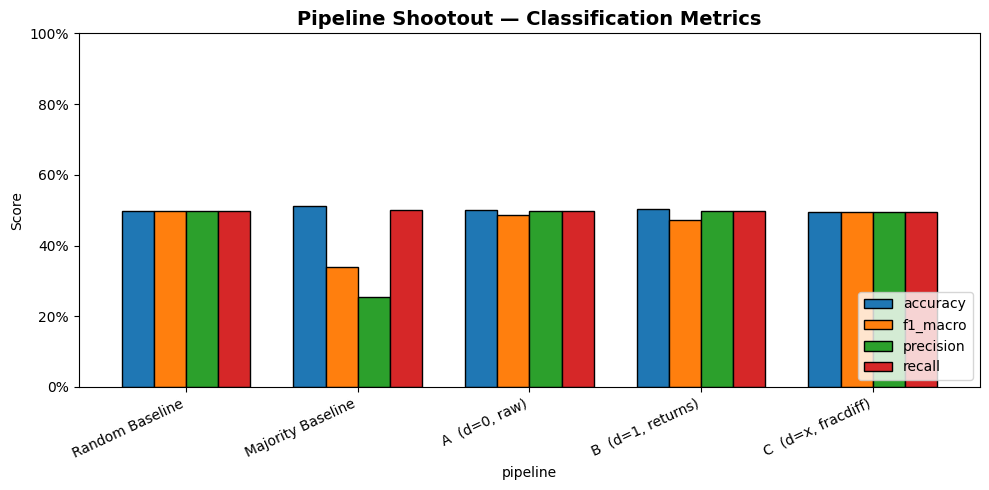

In [39]:
# ═══════════════════════════════════════════════════════════════════════════════
# 11a — Metric comparison bar chart
# ═══════════════════════════════════════════════════════════════════════════════
plot_df = pd.DataFrame(results).set_index("pipeline")
metrics_to_plot = ["accuracy", "f1_macro", "precision", "recall"]

fig, ax = plt.subplots(figsize=(10, 5))
plot_df[metrics_to_plot].astype(float).plot.bar(ax=ax, edgecolor="black", width=0.75)
ax.set_title("Pipeline Shootout — Classification Metrics", fontsize=14, weight="bold")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.legend(loc="lower right")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

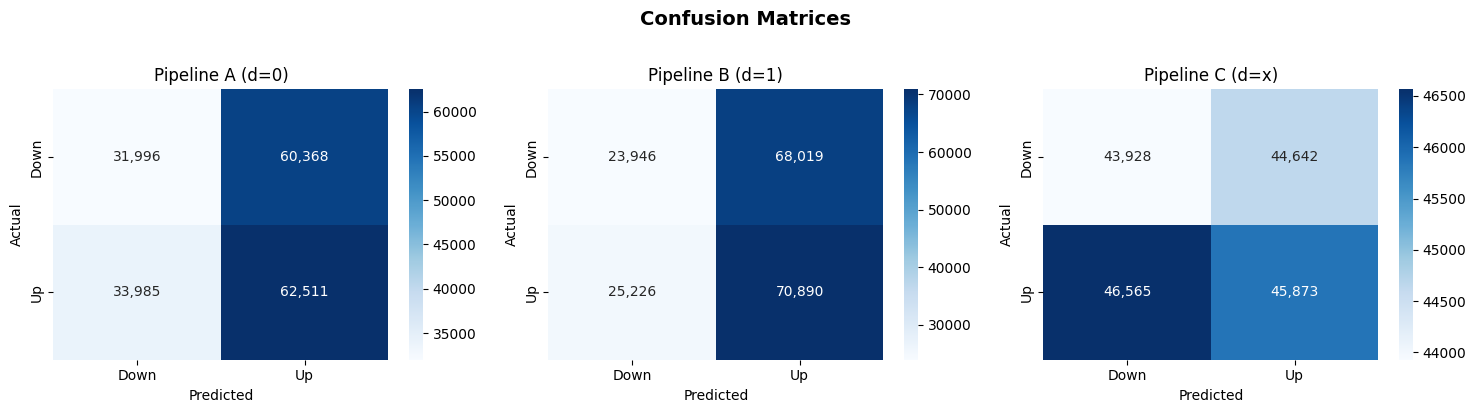

In [40]:
# ═══════════════════════════════════════════════════════════════════════════════
# 11b — Confusion matrices (side-by-side heat-maps)
# ═══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (label, yt, yp) in zip(axes, [
    ("A (d=0)", y_test_a, pred_a),
    ("B (d=1)", y_test_b, pred_b),
    ("C (d=x)", y_test_c, pred_c),
]):
    cm = confusion_matrix(yt, yp)
    sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", ax=ax,
                xticklabels=["Down", "Up"], yticklabels=["Down", "Up"])
    ax.set_title(f"Pipeline {label}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Confusion Matrices", fontsize=14, weight="bold", y=1.02)
plt.tight_layout()
plt.show()

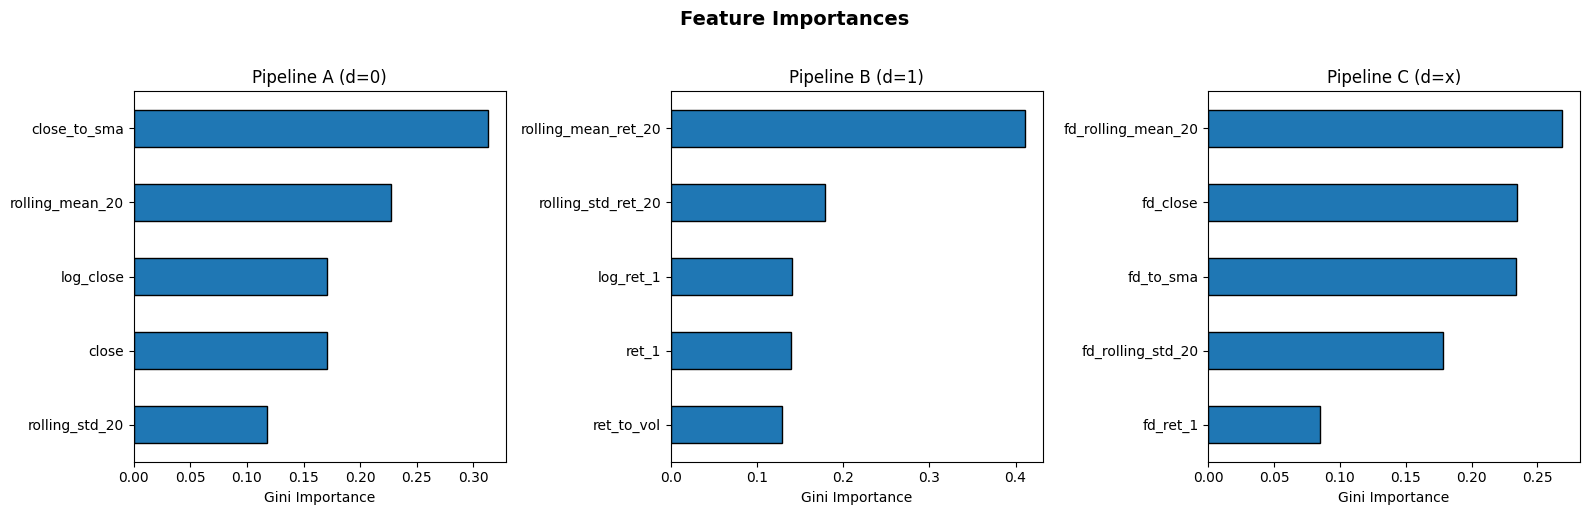

In [41]:
# ═══════════════════════════════════════════════════════════════════════════════
# 11c — Feature importance comparison
# ═══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)

for ax, (label, model, cols) in zip(axes, [
    ("A (d=0)", rf_a, FEATURES_A),
    ("B (d=1)", rf_b, FEATURES_B),
    ("C (d=x)", rf_c, FEATURES_C),
]):
    imp = pd.Series(model.feature_importances_, index=cols).sort_values()
    imp.plot.barh(ax=ax, edgecolor="black")
    ax.set_title(f"Pipeline {label}")
    ax.set_xlabel("Gini Importance")

plt.suptitle("Feature Importances", fontsize=14, weight="bold", y=1.02)
plt.tight_layout()
plt.show()

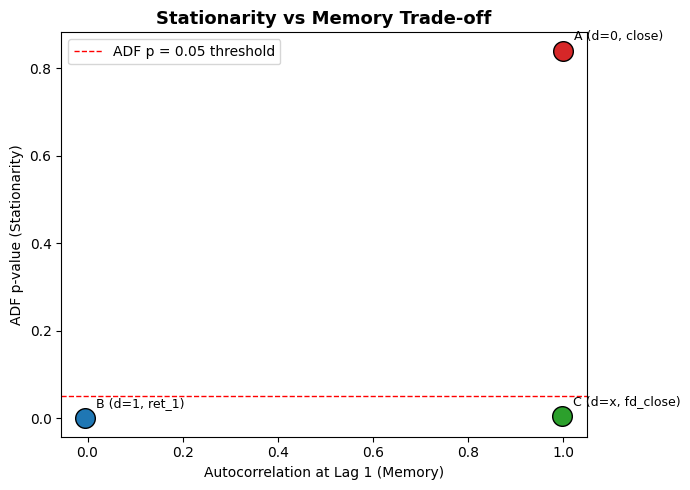

In [42]:
# ═══════════════════════════════════════════════════════════════════════════════
# 11d — Stationarity vs Memory scatter
# ═══════════════════════════════════════════════════════════════════════════════
scatter_data = diag_df.copy()
scatter_data["ADF_pvalue"] = scatter_data["ADF_pvalue"].astype(float)

fig, ax = plt.subplots(figsize=(7, 5))
colors = {"A (d=0, close)": "tab:red", "B (d=1, ret_1)": "tab:blue", "C (d=x, fd_close)": "tab:green"}
for idx, row in scatter_data.iterrows():
    ax.scatter(row["autocorr_lag1"], row["ADF_pvalue"],
               s=200, c=colors.get(idx, "gray"), edgecolors="black", zorder=5)
    ax.annotate(idx, (row["autocorr_lag1"], row["ADF_pvalue"]),
                textcoords="offset points", xytext=(8, 8), fontsize=9)

ax.axhline(0.05, color="red", ls="--", lw=1, label="ADF p = 0.05 threshold")
ax.set_xlabel("Autocorrelation at Lag 1 (Memory)")
ax.set_ylabel("ADF p-value (Stationarity)")
ax.set_title("Stationarity vs Memory Trade-off", fontsize=13, weight="bold")
ax.legend()
plt.tight_layout()
plt.show()

## 12 — Summary

The table below collects the final shootout results across all three pipelines
plus the two baselines.  The key take-away:

- **Pipeline A (d = 0)** uses raw prices — non-stationary, high memory, prone to
  spurious regression.
- **Pipeline B (d = 1)** uses returns — stationary, but discards long-range
  memory that may be predictive.
- **Pipeline C (d = x)** uses fractionally-differenced prices — stationary *and*
  retains partial memory, aiming for the best of both worlds.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# Final shootout table
# ═══════════════════════════════════════════════════════════════════════════════
final = pd.DataFrame(results).set_index("pipeline")

# Append stationarity & memory info
stat_map = diag_df[["stationary_5pct", "autocorr_lag1"]].to_dict("index")
pipe_map = {
    "A  (d=0, raw)":      "A (d=0, close)",
    "B  (d=1, returns)":  "B (d=1, ret_1)",
    "C  (d=x, fracdiff)": "C (d=x, fd_close)",
}
for pipe, diag_key in pipe_map.items():
    if pipe in final.index and diag_key in stat_map:
        final.loc[pipe, "stationary"] = stat_map[diag_key].get("stationary_5pct", "")
        final.loc[pipe, "memory_AC1"] = stat_map[diag_key].get("autocorr_lag1", np.nan)

display(final)

# Highlight winner
numeric_cols = ["accuracy", "f1_macro", "precision", "recall"]
model_rows = [r for r in final.index if "Baseline" not in r]
model_final = final.loc[model_rows, numeric_cols].astype(float)
best_pipe = model_final["f1_macro"].idxmax()
print(f"\n★  Best F1-macro: {best_pipe}  ({model_final.loc[best_pipe, 'f1_macro']:.4f})")
print("Done.")

,accuracy,f1_macro,precision,recall,log_loss,stationary,memory_AC1
pipeline,,,,,,,
Random Baseline,0.498634,0.498570,0.498627,0.498626,0.693147,NaN,NaN
Majority Baseline,0.510939,0.338160,0.255470,0.500000,0.692908,NaN,NaN
"A (d=0, raw)",0.500408,0.487016,0.496824,0.497111,0.693396,NO,0.9999
"B (d=1, returns)",0.504230,0.471292,0.498659,0.498964,0.693256,Yes,-0.0049
"C (d=x, fracdiff)",0.496116,0.496058,0.496115,0.496113,0.693368,Yes,0.9978



★  Best F1-macro: C  (d=x, fracdiff)  (0.4961)
Done.


: 